=== СИСТЕМА РАСПОЗНАВАНИЯ РУКОПИСНЫХ СИМВОЛОВ ===
Найдена директория './data'. Запуск с реальными данными...
=== Этап 1: Подготовка данных ===
Обнаружено символов: 21
Символы: ['5', '*', ',', 'h', '2', '(', '3', '9', 'w', 'y', 't', '0', '+', '8', 'x', '6', '1', ')', '-', '4', '7']
Загружено изображений: 420
Обучающая выборка: 336, Тестовая: 84

=== Этап 2: Обучение моделей k-NN ===
Обучение KNN-k=1...
KNN-k=1: Точность = 0.2619
Обучение KNN-k=3...
KNN-k=3: Точность = 0.2381
Обучение KNN-k=5...
KNN-k=5: Точность = 0.1786
Обучение KNN-k=7...
KNN-k=7: Точность = 0.1548

Лучшая модель: KNN-k=1 с точностью 0.2619

=== Этап 3: Тестирование на новой последовательности ===
Генерируемая последовательность: ['4', ',', ')', '5', '*']


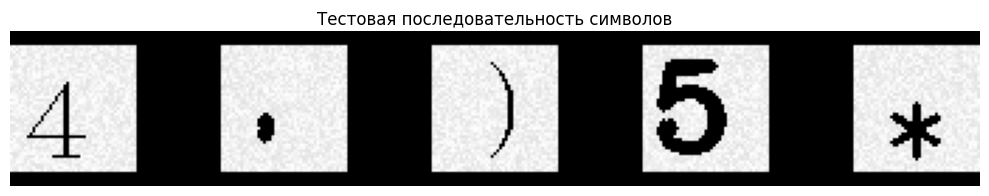

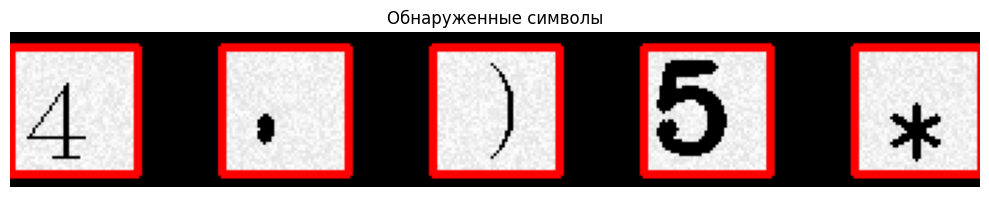


=== Результаты распознавания ===
Ожидаемая последовательность: 4 , ) 5 *
Распознанная последовательность: 4 , ) 5 *
Точность распознавания: 100.00%

=== ИТОГИ РАБОТЫ ===
Итоговая точность: 100.00%
Количество правильно распознанных символов: 5/5


In [6]:
import os
import random
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


class HandwritingDataProcessor:
    """Класс для обработки данных рукописных символов"""

    def __init__(self, dataset_path: str, train_proportion: float = 0.8):
        self.dataset_path = dataset_path
        self.train_proportion = train_proportion

    def load_training_samples(self):
        """Загрузка и подготовка обучающих данных"""
        if not os.path.exists(self.dataset_path):
            raise FileNotFoundError(f"Директория {self.dataset_path} не найдена")

        feature_vectors = []
        labels = []

        symbol_folders = self._scan_symbol_directories()
        if not symbol_folders:
            raise ValueError(f"В директории {self.dataset_path} не найдены папки с символами")

        print(f"Обнаружено символов: {len(symbol_folders)}")
        print(f"Символы: {symbol_folders}")

        for symbol_name in symbol_folders:
            symbol_path = os.path.join(self.dataset_path, symbol_name)

            if not os.path.exists(symbol_path):
                print(f"Предупреждение: папка '{symbol_path}' не существует")
                continue

            try:
                image_files = sorted([
                    f for f in os.listdir(symbol_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
                ])
            except FileNotFoundError:
                print(f"Предупреждение: не удалось прочитать папку '{symbol_path}'")
                continue

            if not image_files:
                print(f"Предупреждение: в папке '{symbol_name}' нет изображений")
                continue

            normalized_label = self._convert_symbol_name(symbol_name)

            for img_file in image_files:
                img_full_path = os.path.join(symbol_path, img_file)
                vector = self._image_to_vector(img_full_path)

                if vector is not None:
                    feature_vectors.append(vector)
                    labels.append(normalized_label)
                else:
                    print(f"Предупреждение: не удалось загрузить изображение {img_full_path}")

        if not feature_vectors:
            raise ValueError(f"Не удалось загрузить ни одного изображения из {self.dataset_path}")

        X = np.array(feature_vectors)
        y = np.array(labels)
        print(f"Загружено изображений: {len(X)}")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=self.train_proportion,
            stratify=y, random_state=42
        )

        print(f"Обучающая выборка: {len(X_train)}, Тестовая: {len(X_test)}")
        return X_train, X_test, y_train, y_test

    def _scan_symbol_directories(self):
        """Сканирование директорий с символами"""
        try:
            all_items = os.listdir(self.dataset_path)
            symbol_folders = [
                item for item in all_items
                if os.path.isdir(os.path.join(self.dataset_path, item))
                and not item.startswith('.')
            ]
            return symbol_folders
        except (StopIteration, FileNotFoundError):
            return []

    @staticmethod
    def _convert_symbol_name(symbol: str) -> str:
        """Нормализация названий символов"""
        conversion_map = {'X': 'x', 'times': '*'}
        return conversion_map.get(symbol, symbol)

    @staticmethod
    def _image_to_vector(image_path: str):
        """Преобразование изображения в вектор признаков"""
        try:
            image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
            if image is None:
                return None
            return image.flatten()
        except Exception as e:
            print(f"Ошибка при загрузке {image_path}: {e}")
            return None


class SymbolSequenceCreator:
    """Генератор последовательностей рукописных символов"""

    def __init__(self, data_directory: str, gap_between_symbols: int = 30):
        self.data_directory = data_directory
        self.gap = gap_between_symbols

        if not os.path.exists(self.data_directory):
            raise FileNotFoundError(f"Директория {self.data_directory} не найдена")

    def generate_sequence(self, symbol_count: int):
        """Создание изображения с последовательностью символов"""
        symbols, symbol_images = self._prepare_symbol_sequence(symbol_count)

        if not symbol_images:
            raise ValueError("Не удалось загрузить изображения символов")

        total_width = sum(img.shape[1] for img in symbol_images) + \
                     self.gap * (len(symbol_images) - 1)
        max_height = max(img.shape[0] for img in symbol_images) + 10

        sequence_canvas = np.ones((max_height, total_width), dtype=np.uint8) * 255

        current_x = 0
        for symbol_img in symbol_images:
            h, w = symbol_img.shape
            y_pos = (max_height - h) // 2
            sequence_canvas[y_pos:y_pos + h, current_x:current_x + w] = symbol_img
            current_x += w + self.gap


        return symbols, cv.bitwise_not(sequence_canvas)

    def _prepare_symbol_sequence(self, length: int):
        """Подготовка случайной последовательности символов"""
        available_symbols = self._get_available_symbols()
        if not available_symbols:
            raise ValueError(f"В директории {self.data_directory} нет доступных символов")

        selected_symbols = random.choices(available_symbols, k=length)
        normalized_symbols = [self._convert_symbol_name(s) for s in selected_symbols]

        print(f"Генерируемая последовательность: {normalized_symbols}")

        loaded_images = []
        for char in selected_symbols:
            symbol_img = self._load_random_symbol_image(char)
            if symbol_img is not None:
                loaded_images.append(symbol_img)

        return normalized_symbols, loaded_images

    def _load_random_symbol_image(self, symbol_folder: str):
        """Загрузка случайного изображения символа"""
        folder_path = os.path.join(self.data_directory, symbol_folder)

        if not os.path.exists(folder_path):
            print(f"Предупреждение: папка '{folder_path}' не существует")
            return None

        try:
            available_images = sorted([
                f for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
            ])
        except FileNotFoundError:
            print(f"Предупреждение: не удалось прочитать папку '{folder_path}'")
            return None

        if not available_images:
            print(f"Предупреждение: в папке '{symbol_folder}' нет изображений")
            return None

        chosen_image = random.choice(available_images)
        full_image_path = os.path.join(folder_path, chosen_image)

        try:
            img_data = cv.imread(full_image_path, cv.IMREAD_GRAYSCALE)
            if img_data is None:
                print(f"Предупреждение: не удалось загрузить изображение {full_image_path}")
            return img_data
        except Exception as e:
            print(f"Ошибка при загрузке {full_image_path}: {e}")
            return None

    def _get_available_symbols(self):
        """Получение списка доступных символов"""
        try:
            all_items = os.listdir(self.data_directory)
            return [
                name for name in all_items
                if os.path.isdir(os.path.join(self.data_directory, name))
                and not name.startswith('.')
            ]
        except FileNotFoundError:
            return []

    @staticmethod
    def _convert_symbol_name(symbol: str) -> str:
        """Нормализация названий символов"""
        mapping = {'X': 'x', 'times': '*'}
        return mapping.get(symbol, symbol)


class CharacterDetector:
    """Класс для обнаружения и извлечения символов из изображения"""

    def __init__(self, padding_size: tuple = (45, 45)):
        self.padding_size = padding_size

    def extract_characters(self, binary_image):
        """Обнаружение и извлечение отдельных символов"""

        if len(binary_image.shape) == 3:
            gray_image = cv.cvtColor(binary_image, cv.COLOR_RGB2GRAY)
        else:
            gray_image = binary_image

        _, thresholded = cv.threshold(gray_image, 127, 255, cv.THRESH_BINARY)

        contours, _ = cv.findContours(
            thresholded,
            cv.RETR_EXTERNAL,
            cv.CHAIN_APPROX_SIMPLE
        )

        character_regions = []
        for contour in contours:
            x, y, w, h = cv.boundingRect(contour)
            if w * h > 50:
                character_regions.append((x, y, w, h))

        character_regions.sort(key=lambda r: r[0])
        return character_regions

    def prepare_character(self, character_img, target_size=(45, 45)):
        """Подготовка символа к классификации"""
        h, w = character_img.shape
        target_h, target_w = target_size

        if h == target_h and w == target_w:
            return character_img

        if h > target_h or w > target_w:
            non_zero_rows = np.where(np.max(character_img, axis=1) > 10)[0]
            non_zero_cols = np.where(np.max(character_img, axis=0) > 10)[0]

            if len(non_zero_rows) > 0 and len(non_zero_cols) > 0:
                y1, y2 = non_zero_rows[0], non_zero_rows[-1] + 1
                x1, x2 = non_zero_cols[0], non_zero_cols[-1] + 1
                character_img = character_img[y1:y2, x1:x2]

            h, w = character_img.shape
            scale_factor = min(target_h / h, target_w / w)
            if scale_factor < 1.0:
                new_h, new_w = int(h * scale_factor), int(w * scale_factor)
                character_img = cv.resize(character_img, (new_w, new_h))

        return self._add_padding(character_img, target_size)

    def _add_padding(self, img, target_size):
        """Добавление отступов к изображению"""
        h, w = img.shape
        target_h, target_w = target_size

        padded = np.zeros(target_size, dtype=np.uint8)
        y_start = (target_h - h) // 2
        x_start = (target_w - w) // 2

        padded[y_start:y_start+h, x_start:x_start+w] = img
        return padded


class KNNModelEvaluator:
    """Оценка и сравнение моделей k-NN с различными параметрами"""

    def __init__(self):
        self.trained_models = {}

    def train_and_evaluate(self, X_train, X_test, y_train, y_test, k_values=[1, 3, 5, 7]):
        """Обучение и оценка моделей с разными значениями k"""
        for k in k_values:
            model_name = f"KNN-k={k}"
            print(f"Обучение {model_name}...")

            knn_model = KNeighborsClassifier(n_neighbors=k)
            knn_model.fit(X_train, y_train)

            predictions = knn_model.predict(X_test)
            model_accuracy = accuracy_score(y_test, predictions)

            self.trained_models[model_name] = {
                'model': knn_model,
                'accuracy': model_accuracy
            }

            print(f"{model_name}: Точность = {model_accuracy:.4f}")

    def select_best_model(self):
        """Выбор модели с наивысшей точностью"""
        if not self.trained_models:
            return None, None, None

        best_model_name = max(
            self.trained_models.keys(),
            key=lambda x: self.trained_models[x]['accuracy']
        )
        best_model_info = self.trained_models[best_model_name]

        return best_model_name, best_model_info['model'], best_model_info['accuracy']


def visualize_image(image_array, title="Изображение", cmap='gray'):
    """Визуализация изображения"""
    plt.figure(figsize=(10, 8))
    plt.imshow(image_array, cmap=cmap)
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def demo_with_sample_data():
    """Демонстрация работы с тестовыми данными"""
    print("=== ДЕМОНСТРАЦИОННЫЙ РЕЖИМ ===")
    print("Создание тестовых данных...")

    test_symbols = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

    import tempfile
    import shutil

    temp_dir = tempfile.mkdtemp()
    print(f"Создана временная директория: {temp_dir}")

    try:
        for symbol in test_symbols:
            symbol_dir = os.path.join(temp_dir, symbol)
            os.makedirs(symbol_dir, exist_ok=True)

            for i in range(5):
                img = np.zeros((45, 45), dtype=np.uint8)

                cv.putText(img, symbol, (5, 35), cv.FONT_HERSHEY_SIMPLEX,
                          1.0, 255, 2)

                img_path = os.path.join(symbol_dir, f"{symbol}_{i}.png")
                cv.imwrite(img_path, img)

        result = main_workflow(temp_dir)
        return result

    finally:
        shutil.rmtree(temp_dir)
        print(f"Временная директория удалена: {temp_dir}")


def main_workflow(data_path=None):
    """Основной рабочий процесс"""
    if data_path is None:
        DATA_PATH = './data'
    else:
        DATA_PATH = data_path

    try:
        print("=== Этап 1: Подготовка данных ===")
        data_processor = HandwritingDataProcessor(DATA_PATH)
        X_train, X_test, y_train, y_test = data_processor.load_training_samples()

        print("\n=== Этап 2: Обучение моделей k-NN ===")
        model_evaluator = KNNModelEvaluator()
        model_evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)

        best_name, best_model, best_acc = model_evaluator.select_best_model()
        print(f"\nЛучшая модель: {best_name} с точностью {best_acc:.4f}")

        print("\n=== Этап 3: Тестирование на новой последовательности ===")
        sequence_generator = SymbolSequenceCreator(DATA_PATH)
        true_labels, test_image = sequence_generator.generate_sequence(5)

        visualize_image(test_image, "Тестовая последовательность символов")

        detector = CharacterDetector()

        _, binary_test = cv.threshold(test_image, 127, 255, cv.THRESH_BINARY)
        character_boxes = detector.extract_characters(binary_test)

        marked_image = cv.cvtColor(test_image, cv.COLOR_GRAY2RGB)
        for (x, y, w, h) in character_boxes:
            cv.rectangle(marked_image, (x, y), (x + w, y + h), (255, 0, 0), 2)
        visualize_image(marked_image, "Обнаруженные символы", cmap=None)

        character_images = []
        for (x, y, w, h) in character_boxes:
            char_img = test_image[y:y+h, x:x+w]


            prepared_char = detector.prepare_character(char_img)
            character_images.append(prepared_char)

        predicted_labels = []
        for char_img in character_images:
            char_vector = cv.bitwise_not(char_img).flatten()
            prediction = best_model.predict([char_vector])[0]
            predicted_labels.append(prediction)

        print("\n=== Результаты распознавания ===")
        print(f"Ожидаемая последовательность: {' '.join(true_labels)}")
        print(f"Распознанная последовательность: {' '.join(predicted_labels)}")

        correct_predictions = sum(1 for p, t in zip(predicted_labels, true_labels) if p == t)
        recognition_accuracy = correct_predictions / len(true_labels)
        print(f"Точность распознавания: {recognition_accuracy:.2%}")

        return recognition_accuracy, best_model, true_labels, predicted_labels

    except Exception as e:
        print(f"Произошла ошибка: {e}")
        print(f"Тип ошибки: {type(e).__name__}")
        import traceback
        traceback.print_exc()
        return None, None, None, None


if __name__ == "__main__":
    print("=== СИСТЕМА РАСПОЗНАВАНИЯ РУКОПИСНЫХ СИМВОЛОВ ===")

    if not os.path.exists('./data'):
        print("Директория './data' не найдена. Запуск демонстрационного режима...")
        result = demo_with_sample_data()

        if result[0] is not None:
            accuracy, model, expected, predicted = result
            print(f"\n=== ИТОГИ ДЕМОНСТРАЦИИ ===")
            print(f"Итоговая точность: {accuracy:.2%}")
            print(f"Количество правильно распознанных символов: "
                  f"{sum(1 for e, p in zip(expected, predicted) if e == p)}/{len(expected)}")
    else:
        print("Найдена директория './data'. Запуск с реальными данными...")
        accuracy, model, expected, predicted = main_workflow()

        if accuracy is not None:
            print(f"\n=== ИТОГИ РАБОТЫ ===")
            print(f"Итоговая точность: {accuracy:.2%}")
            print(f"Количество правильно распознанных символов: "
                  f"{sum(1 for e, p in zip(expected, predicted) if e == p)}/{len(expected)}")